INITIALISING THE IMPORTANT STUFF

In [23]:
import pandas as pd

df = pd.read_csv("details_v3.csv")

In [24]:
df.head(5)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [25]:
df.shape

(8128, 13)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [27]:
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [28]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,221
engine,221


In [29]:
df["mileage"].head(10)

,mileage
0,23.4 kmpl
1,21.14 kmpl
2,17.7 kmpl
3,23.0 kmpl
4,16.1 kmpl
5,20.14 kmpl
6,17.3 km/kg
7,16.1 kmpl
8,23.59 kmpl
9,20.0 kmpl


In [30]:
df["engine"].head(10)

,engine
0,1248 CC
1,1498 CC
2,1497 CC
3,1396 CC
4,1298 CC
5,1197 CC
6,1061 CC
7,796 CC
8,1364 CC
9,1399 CC


In [31]:
df["max_power"].head(10)

,max_power
0,74 bhp
1,103.52 bhp
2,78 bhp
3,90 bhp
4,88.2 bhp
5,81.86 bhp
6,57.5 bhp
7,37 bhp
8,67.1 bhp
9,68.1 bhp


In [32]:
df["fuel"].unique()

array(['Diesel', 'Petrol', 'LPG', 'CNG'], dtype=object)

In [33]:
df["mileage"].str.contains(pat='kmpl').sum()

7819

In [34]:
df["mileage"].str.contains(pat='km/kg').sum()

88

In [35]:
df["fuel"].str.contains(pat='LPG').sum()

np.int64(38)

In [36]:
df["fuel"].str.contains(pat='CNG').sum() #95 total

np.int64(57)

In [37]:
def convert_and_scale(x):
    # Ensure the value is a string before checking units
    val = str(x)
    if 'km/kg' in val:
        # Extract the number (e.g., '12.0 km/kg' -> 12.0), multiply by 1.4
        return float(val.split()[0]) * 1.4
    elif 'kmpl' in val:
        # Just extract the number and convert to float without multiplying
        return float(val.split()[0])
    return x
# Apply the function to the column to overwrite it with floats
df["mileage"] = df["mileage"].apply(convert_and_scale)

In [38]:
df["mileage"].head(5)

,mileage
0,23.40
1,21.14
2,17.70
3,23.00
4,16.10


In [39]:
df["mileage"].isnull().sum() #221 missing values

np.int64(221)

In [40]:
df["engine"] = df["engine"].str.strip("CC")

In [41]:
df["engine"].head(5)

,engine
0,1248
1,1498
2,1497
3,1396
4,1298


In [42]:
df["engine"] = df["engine"].astype(float)

In [43]:
df["max_power"].head()

,max_power
0,74 bhp
1,103.52 bhp
2,78 bhp
3,90 bhp
4,88.2 bhp


In [44]:
df["max_power"] = df["max_power"].str.strip(" bhp")

In [45]:
df["max_power"].head()

,max_power
0,74
1,103.52
2,78
3,90
4,88.2


In [46]:
df["max_power"] = pd.to_numeric(df["max_power"].str.replace(" bhp", "", regex=False).str.strip(), errors='coerce')

In [47]:
df["max_power"].dtype

dtype('float64')

In [48]:
df["engine"].isnull().sum()

np.int64(221)

In [49]:
df["mileage"].isnull().sum()

np.int64(221)

In [50]:
df["max_power"].isnull().sum()

np.int64(216)

CHECK THE SKEWNESS OF FEATURES TO FILL NULL VALS

In [51]:
df["mileage"].skew()

np.float64(0.31133846655962555)

In [52]:
df["engine"]

,engine
0,1248.0
1,1498.0
2,1497.0
3,1396.0
4,1298.0
...,...
8123,1197.0
8124,1493.0
8125,1248.0
8126,1396.0


In [53]:
df["engine"].skew()

np.float64(1.1352691298499176)

In [54]:
df["max_power"].skew()

np.float64(1.6212607481144414)

In [55]:
df["seats"].skew()

np.float64(1.969914080776506)

In [56]:
df["selling_price"].skew()

np.float64(4.193533440675855)

filling null values with median

In [57]:
df["mileage"] = df["mileage"].fillna(df.mileage.median())

In [58]:
df["mileage"].isnull().sum()

np.int64(0)

In [59]:
df["engine"] = df["engine"].fillna(df.engine.median())

In [60]:
df["engine"].isnull().sum()

np.int64(0)

In [61]:
df["max_power"] = df["max_power"].fillna(df.max_power.median())

In [62]:
df["max_power"].isnull().sum()

np.int64(0)

In [63]:
df["seats"] = df["seats"].fillna(df.seats.median())

In [64]:
df["seats"].isnull().sum()

np.int64(0)

CLEANING THE MOST MESSED UP (TORQUE) COLUMN

In [65]:
df["torque"].isnull().sum()

np.int64(222)

In [66]:
df["torque"].head(15)

,torque
0,190Nm@ 2000rpm
1,250Nm@ 1500-2500rpm
2,"12.7@ 2,700(kgm@ rpm)"
3,22.4 kgm at 1750-2750rpm
4,"11.5@ 4,500(kgm@ rpm)"
5,113.75nm@ 4000rpm
6,"7.8@ 4,500(kgm@ rpm)"
7,59Nm@ 2500rpm
8,170Nm@ 1800-2400rpm
9,160Nm@ 2000rpm


In [67]:
df["torque"].nunique()

441

In [68]:
import re
import numpy as np

def extract_torque(torque_str):
    if pd.isnull(torque_str):
        return np.nan

    # find the number at the start
    match = re.search(r'([\d.]+)', torque_str)
    if not match:
        return np.nan

    value = float(match.group(1))

    # if unit is kgm then convert to Nm by multiplying with 9.8
    if 'kgm' in torque_str.lower():
        value = value * 9.8

    return value

In [69]:
df["torque"].head(10)

,torque
0,190Nm@ 2000rpm
1,250Nm@ 1500-2500rpm
2,"12.7@ 2,700(kgm@ rpm)"
3,22.4 kgm at 1750-2750rpm
4,"11.5@ 4,500(kgm@ rpm)"
5,113.75nm@ 4000rpm
6,"7.8@ 4,500(kgm@ rpm)"
7,59Nm@ 2500rpm
8,170Nm@ 1800-2400rpm
9,160Nm@ 2000rpm


In [70]:
def extract_rpm(torque_str):
    if pd.isnull(torque_str):
        return np.nan
    # find the number after the @ symbol
    match = re.search(r'@\s*([\d,]+)', torque_str)
    if not match:
        return np.nan

    # remove commas like 2,500 → 2500
    rpm_value = match.group(1).replace(',', '')

    return float(rpm_value)

In [71]:
# apply both functions
df['torque_nm'] = df['torque'].apply(extract_torque)
df['max_torque_rpm'] = df['torque'].apply(extract_rpm)

# drop the original messy torque column
df.drop(columns=['torque'], inplace=True)

In [72]:
df["torque_nm"].isnull().sum() #222 nulls in torque_nm column

np.int64(222)

In [73]:
df["max_torque_rpm"].isnull().sum() #487 nulls in torque_nm column

np.int64(487)

In [74]:
df["torque_nm"] = df["torque_nm"].fillna(df.torque_nm.median())

In [75]:
df["max_torque_rpm"] = df["max_torque_rpm"].fillna(df.max_torque_rpm.median())

In [76]:
df["torque_nm"].isnull().sum()

np.int64(0)

In [77]:
df["max_torque_rpm"].isnull().sum()

np.int64(0)

EXPLORATORY DATA ANALYSIS

In [78]:
df.describe()

,year,selling_price,km_driven,mileage,engine,max_power,seats,torque_nm,max_torque_rpm
count,8128.000000,8.128000e+03,8.128000e+03,8128.000000,8128.00000,8128.000000,8128.000000,8128.000000,8128.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.511398,1452.89813,91.264982,5.405389,180.715408,2666.282111
std,4.044249,8.062534e+05,5.655055e+04,4.186402,498.19672,35.376388,0.948874,114.661992,1113.915365
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.00000,0.000000,2.000000,47.040000,175.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.800000,1197.00000,68.100000,5.000000,112.000000,1750.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.330000,1248.00000,82.000000,5.000000,170.000000,2000.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.00000,101.250000,5.000000,205.000000,3800.000000
max,2020.000000,1.000000e+07,2.360457e+06,46.816000,3604.00000,400.000000,14.000000,3724.000000,21800.000000


VISUALIZATION

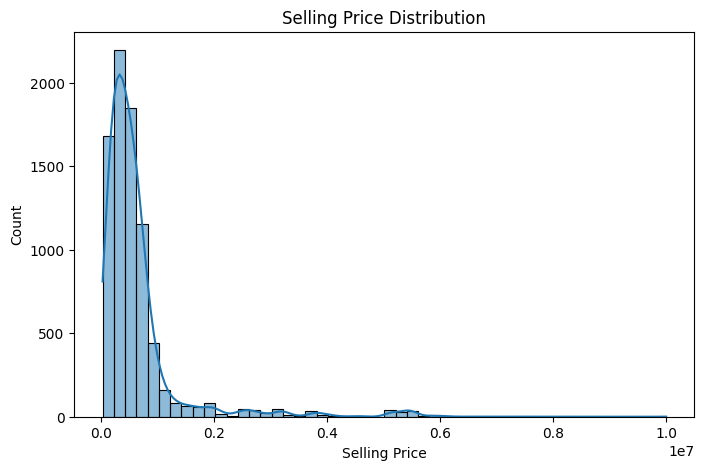

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(df['selling_price'], bins=50, kde=True)
plt.title('Selling Price Distribution')
plt.xlabel('Selling Price')
plt.show()

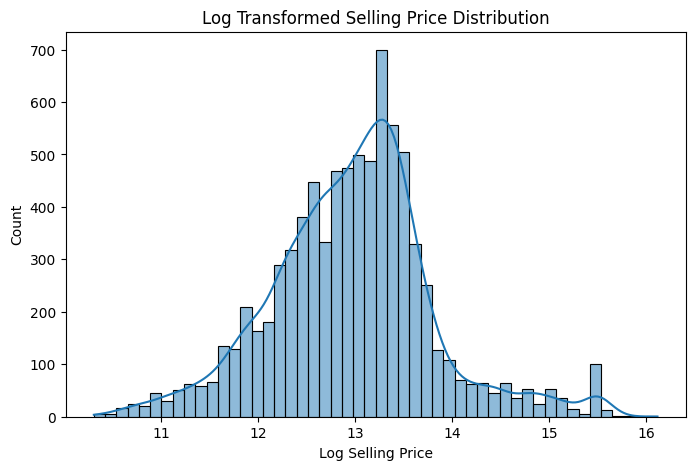

In [80]:
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(df['selling_price']), bins=50, kde=True)
plt.title('Log Transformed Selling Price Distribution')
plt.xlabel('Log Selling Price')
plt.show()

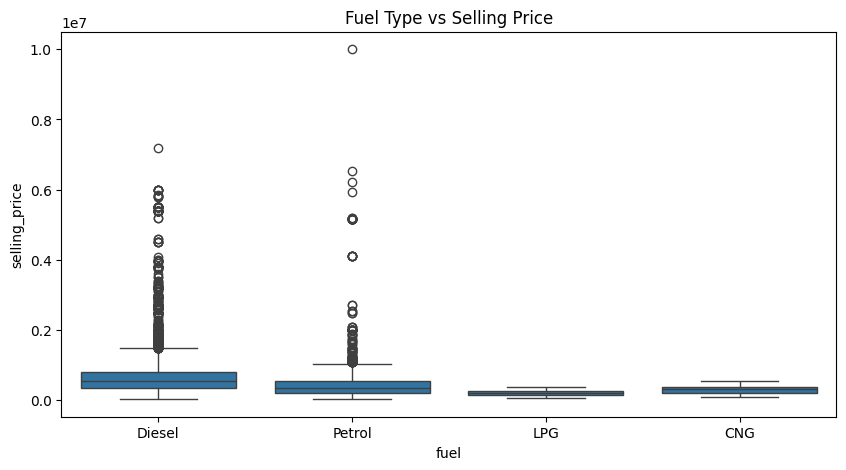

In [81]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='fuel', y='selling_price', data=df)
plt.title('Fuel Type vs Selling Price')
plt.show()

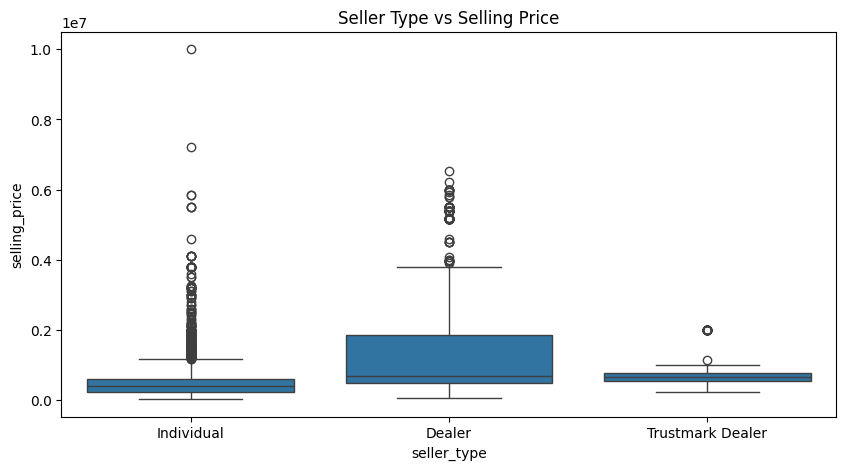

In [82]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='seller_type', y='selling_price', data=df)
plt.title('Seller Type vs Selling Price')
plt.show()

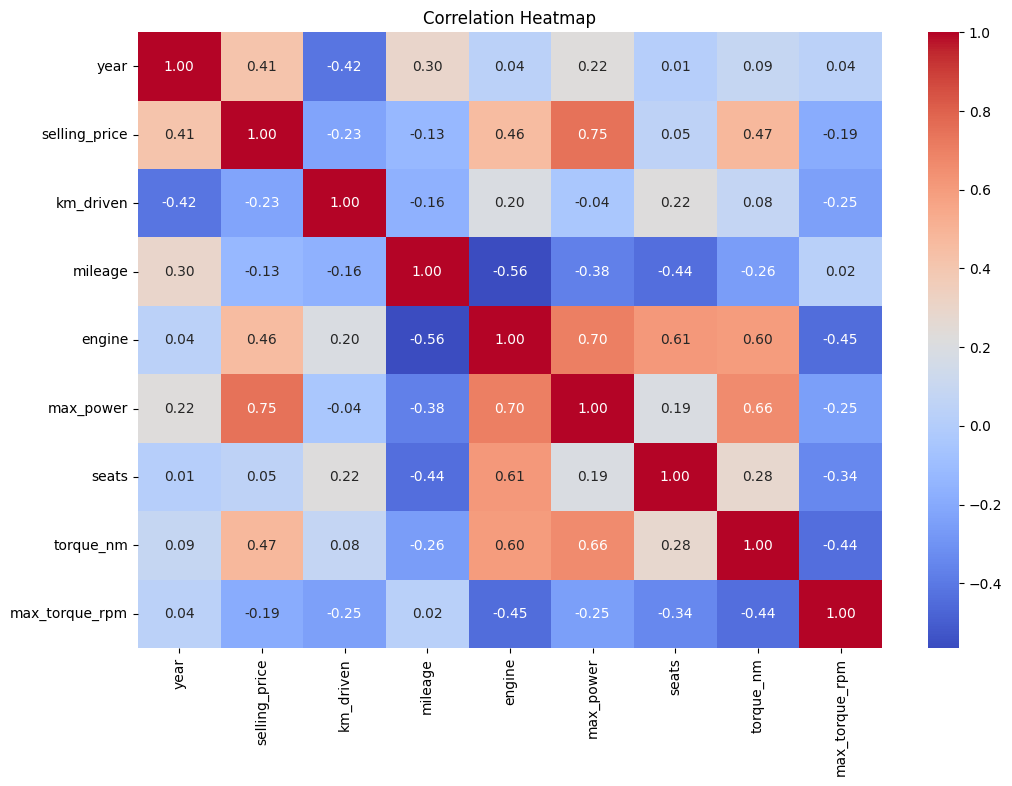

In [83]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            fmt='.2f',
            cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

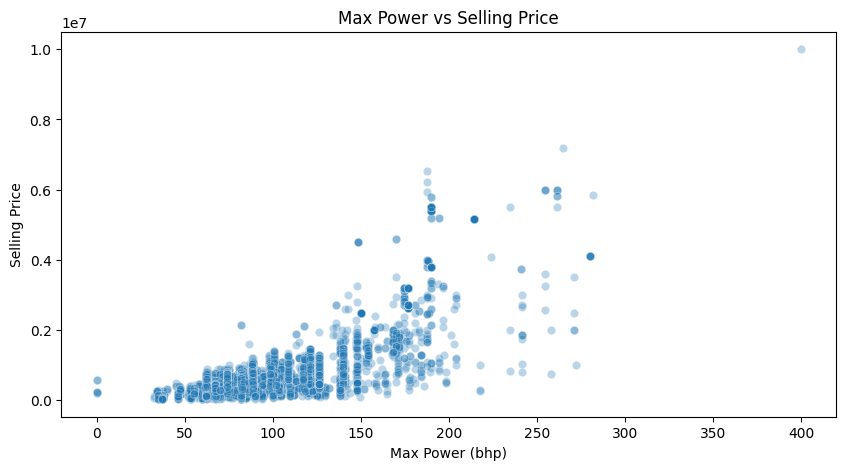

In [84]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='max_power', y='selling_price', data=df, alpha=0.3)
plt.title('Max Power vs Selling Price')
plt.xlabel('Max Power (bhp)')
plt.ylabel('Selling Price')
plt.show()

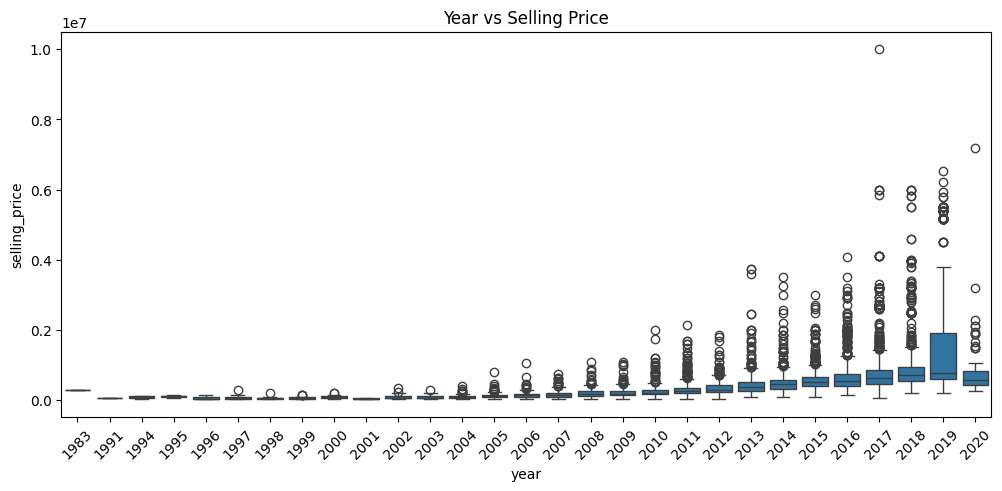

In [85]:
plt.figure(figsize=(12, 5))
sns.boxplot(x='year', y='selling_price', data=df)
plt.title('Year vs Selling Price')
plt.xticks(rotation=45)
plt.show()

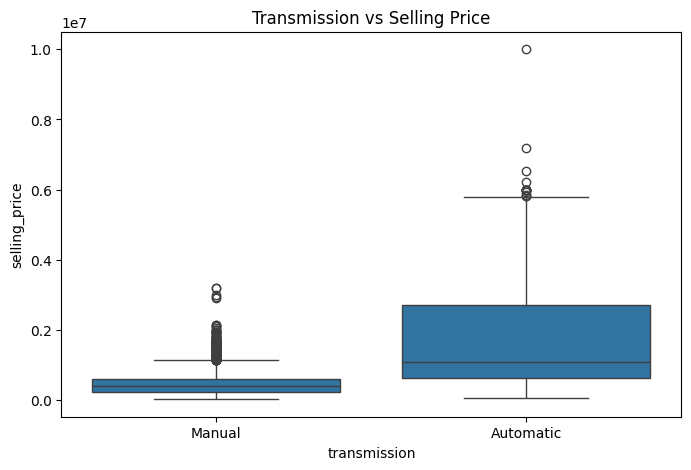

In [86]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='transmission', y='selling_price', data=df)
plt.title('Transmission vs Selling Price')
plt.show()

FEATURE ENGINEERING

In [87]:
df['selling_price'] = np.log1p(df['selling_price'])

In [88]:
df['selling_price'].describe()

,selling_price
count,8128.000000
mean,12.973412
std,0.839131
min,10.308953
25%,12.449019
50%,13.017005
75%,13.422469
max,16.118096


In [89]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats',
       'torque_nm', 'max_torque_rpm'],
      dtype='object')

In [90]:
df.drop(columns=['name'], inplace=True)
print(df.columns)
print(f"Total columns remaining: {len(df.columns)}")

Index(['year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats',
       'torque_nm', 'max_torque_rpm'],
      dtype='object')
Total columns remaining: 13


encoding columns

In [91]:
df = pd.get_dummies(df, columns=['fuel', 'seller_type', 'transmission'], drop_first=True)
owner_map = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5
}

df['owner'] = df['owner'].map(owner_map)


In [92]:
df.shape

(8128, 16)

FINAL CHECK

In [93]:
df.head()

,year,selling_price,km_driven,owner,mileage,engine,max_power,seats,torque_nm,max_torque_rpm,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
0,2014,13.017005,145500,1,23.40,1248.0,74.00,5.0,190.00,2000.0,True,False,False,True,False,True
1,2014,12.821261,120000,2,21.14,1498.0,103.52,5.0,250.00,1500.0,True,False,False,True,False,True
2,2006,11.970357,140000,3,17.70,1497.0,78.00,5.0,124.46,2700.0,False,False,True,True,False,True
3,2010,12.323860,127000,1,23.00,1396.0,90.00,5.0,219.52,2000.0,True,False,False,True,False,True
4,2007,11.775297,120000,1,16.10,1298.0,88.20,5.0,112.70,4500.0,False,False,True,True,False,True


In [94]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(df.dtypes)
print("\nShape:", df.shape)

year                              int64
selling_price                   float64
km_driven                         int64
owner                             int64
mileage                         float64
engine                          float64
max_power                       float64
seats                           float64
torque_nm                       float64
max_torque_rpm                  float64
fuel_Diesel                       int64
fuel_LPG                          int64
fuel_Petrol                       int64
seller_type_Individual            int64
seller_type_Trustmark Dealer      int64
transmission_Manual               int64
dtype: object

Shape: (8128, 16)


MODEL CREATION AND EVALUATION

In [95]:
X = df.drop(columns=['selling_price'])
y = df['selling_price']

In [96]:
X.shape

(8128, 15)

In [97]:
y.shape

(8128,)

In [98]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#standard scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [99]:
X_train_scaled.shape

(6502, 15)

In [100]:
X_test_scaled.shape

(1626, 15)

In [101]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [102]:
# 1. Initialize the model
model = Sequential()
# 2. Add Input & First Hidden Layer
model.add(Dense(64, activation='relu', input_dim=15))
# 3. Add Second Hidden Layer
model.add(Dense(32, activation='relu'))
# 4. Add Output Layer (Linear because it's a regression problem)
model.add(Dense(1, activation='linear'))
# 5. Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
# 6. Show the architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [103]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 48.5618 - mae: 5.4365 - val_loss: 8.6562 - val_mae: 1.4102
Epoch 2/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.6709 - mae: 1.1202 - val_loss: 5.7866 - val_mae: 0.9908
Epoch 3/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3828 - mae: 0.8086 - val_loss: 4.3316 - val_mae: 0.7577
Epoch 4/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8378 - mae: 0.6252 - val_loss: 3.4232 - val_mae: 0.6446
Epoch 5/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5579 - mae: 0.5102 - val_loss: 2.6854 - val_mae: 0.5307
Epoch 6/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3995 - mae: 0.4300 - val_loss: 2.2397 - val_mae: 0.4511
Epoch 7/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2983 - mae: 0.3740 - val_loss: 2.0277 - val_mae: 0.4084
Epoch 8/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2302 - mae: 0.3332 - val_loss: 1.6731 - val_mae: 0.3905
Epoch 9/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms

In [104]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Make predictions on test set
y_pred_log = model.predict(X_test_scaled)

# 2. Reverse the log transformation (Go from log back to Rupees)
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

# 3. Calculate Accuracy (R2 Score)
r2 = r2_score(y_test_actual, y_pred_actual)
mae = mean_absolute_error(y_test_actual, y_pred_actual)

print(f"R2 Score (Accuracy): {r2:.4f}")
print(f"Mean Absolute Error: ₹{mae:,.2f}")

# 4. Compare Actual vs Predicted for first 5 cars
comparison = pd.DataFrame({
    'Actual Price': y_test_actual.values,
    'Predicted Price': y_pred_actual.flatten()
})
print("\nFirst 5 Predictions:")
print(comparison.head())

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
R2 Score (Accuracy): 0.9475
Mean Absolute Error: ₹101,998.62

First 5 Predictions:
   Actual Price  Predicted Price
0      198000.0    117357.750000
1      500000.0    387552.812500
2      425000.0    433060.000000
3      150000.0    166395.546875
4      525000.0    327123.875000


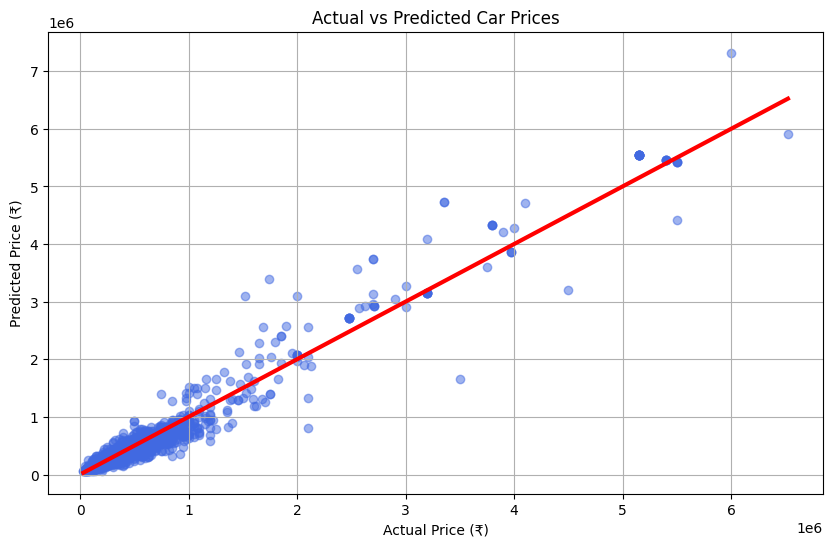

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.5, color='royalblue')
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], color='red', lw=3)
plt.title('Actual vs Predicted Car Prices')
plt.xlabel('Actual Price (₹)')
plt.ylabel('Predicted Price (₹)')
plt.grid(True)
plt.show()

In [106]:
import joblib

# 1. Save the Scaler using joblib
joblib.dump(scaler, 'scaler.joblib')

# 2. (Optional) Save the Keras model again just to be sure
model.save('car_price_model.keras')

print("✅ Scaler saved with joblib!")
print("✅ Model saved with Keras!")

✅ Scaler saved with joblib!
✅ Model saved with Keras!
